In [33]:
from FormUtils import get_form_expr, form5

In [35]:
%%form5 ee_to_mumu
* Process: e+ e- -> mu+ mu-
Indices mu, nu, mu1, nu1;
Symbols s, t, u, e, pi, alpha, costh;
Vectors p1, p2, p3, p4;

* Amplitude Squared (Diagrammatica conventions)
Local Msq = (e^4 / s^2) * 
            d_(mu, mu1) * d_(nu, nu1) * 
            (g_(1, p2) * g_(1, mu) * g_(1, p1) * g_(1, nu)) * 
            (g_(2, p3) * g_(2, mu1) * g_(2, p4) * g_(2, nu1));

* Differential cross section formula
Local dSigma = (1 / (64 * pi^2 * s)) * Msq;

trace4, 1;
trace4, 2;
.sort 
Print Msq; 
.sort
contract;
.sort
Print Msq;
.sort

* Physics & Normalization
id e^4 = 16 * pi^2 * alpha^2;
* Spin averaging (1/2 * 1/2)
multiply 1/4; 

* 3. Kinematics (Massless Limit)
id p1.p1 = 0; id p2.p2 = 0; id p3.p3 = 0; id p4.p4 = 0;
id p1.p2 = s/2; id p3.p4 = s/2;
id p1.p3 = -t/2; id p2.p4 = -t/2;
id p1.p4 = -u/2; id p2.p3 = -u/2;

* 4. Angular dependency
id t = -s/2 * (1 - costh);
id u = -s/2 * (1 + costh);

bracket alpha, s;
Print dSigma;
.end

FORM 5.0.0 (Jan 27 2026, v5.0.0)                 Run: Sun Apr  5 02:52:43 2026
    * Process: e+ e- -> mu+ mu-
    Indices mu, nu, mu1, nu1;
    Symbols s, t, u, e, pi, alpha, costh;
    Vectors p1, p2, p3, p4;
    
    * Amplitude Squared (Diagrammatica conventions)
    Local Msq = (e^4 / s^2) * 
                d_(mu, mu1) * d_(nu, nu1) * 
                (g_(1, p2) * g_(1, mu) * g_(1, p1) * g_(1, nu)) * 
                (g_(2, p3) * g_(2, mu1) * g_(2, p4) * g_(2, nu1));
    
    * Differential cross section formula
    Local dSigma = (1 / (64 * pi^2 * s)) * Msq;
    
    trace4, 1;
    trace4, 2;
    .sort 

Time =       0.00 sec    Generated terms =          2
             Msq         Terms in output =          2
                         Bytes used      =        140

Time =       0.00 sec    Generated terms =          2
          dSigma         Terms in output =          2
                         Bytes used      =        156
    Print Msq; 
    .sort

Time =       0.00 sec    Gene

+s**-1*alpha**2*(1/4+1/4*x**2)


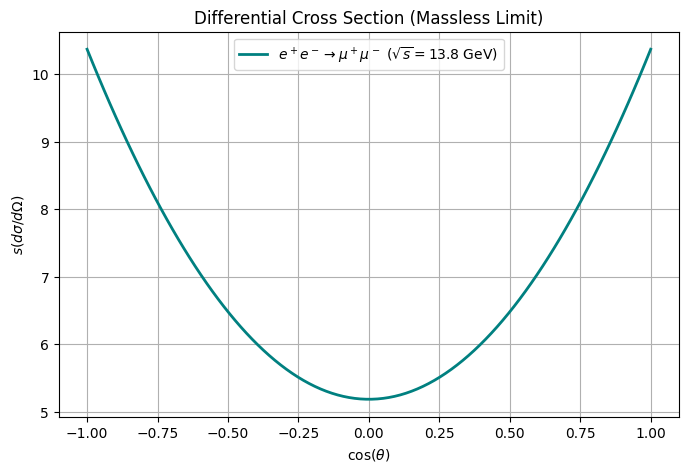

In [31]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-muted') 
plt.rcParams['axes.grid'] = True

# Capture the output from the file
raw_str = get_form_expr("ee_to_mumu", "dSigma")
if raw_str is None:
    print("No FORM output detected. Did the previous cell run successfully?")

# Convert FORM to Python: ^ -> ** and costh -> x
py_expr = raw_str.replace('^', '**').replace('costh', 'x')
print(py_expr)       
# Physical Constants
alpha = 1/137.036
# Center of mass energy squared
s = 13.8**2  # match the 's' in the string

# Prepare data
x = np.linspace(-1, 1, 100)

# Conversion Factors from Natural Units to Cross-Section 
# (0.197327 GeV * fm)^2 = 0.0389379 GeV^2 * fm^2
# 1 GeV^-2 = 0.389379 mb (millibarns)
conv_gev2_to_nb = 389379.0
y_vals = s * eval(py_expr) * conv_gev2_to_nb

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, y_vals, lw=2, color='teal', label=rf'$e^+e^- \to \mu^+\mu^-$ ($\sqrt{{s}}={(np.sqrt(s))}$ GeV)')
plt.title("Differential Cross Section (Massless Limit)")
plt.xlabel(r"$\cos(\theta)$")
plt.ylabel(r"$s (d\sigma/d\Omega)$")
plt.legend()
plt.show()
    


In [32]:
!form ../scripts/ee_to_mumu.frm

FORM 5.0.0 (Jan 27 2026, v5.0.0)                 Run: Wed Apr  1 21:03:19 2026
    * Process: e+ e- -> mu+ mu-
    Indices mu, nu, mu1, nu1;
    Symbols s, t, u, e, pi, alpha, costh;
    Vectors p1, p2, p3, p4;
    
    * Amplitude Squared (Diagrammatica conventions)
    Local Msq = (e^4 / s^2) * d_(mu, mu1) * d_(nu, nu1) * (g_(1, p2) * g_(1, mu) * g
    _(1, p1) * g_(1, nu)) *
        (g_(2, p3) * g_(2, mu1) * g_(2, p4) * g_(2, nu1));
    
    * Differential cross section formula
    Local dSigma = (1 / (64 * pi^2 * s)) * Msq;
    
    trace4, 1;
    trace4, 2;
    .sort 

Time =       0.00 sec    Generated terms =          2
             Msq         Terms in output =          2
                         Bytes used      =        140

Time =       0.00 sec    Generated terms =          2
          dSigma         Terms in output =          2
                         Bytes used      =        156
    Print Msq; 
    .sort

Time =       0.00 sec    Generated terms =          2
             